# How Different SVM Kernels Change Decision Boundaries: A Visual Tutorial

## Objective

This notebook demonstrates how different kernels in Support Vector Machines (SVM) affect decision boundaries on a non-linear dataset.

The aim is to compare:
- Linear kernel
- Polynomial kernel
- Radial Basis Function (RBF) kernel
- Sigmoid

By the end of this notebook, the reader should understand how kernel choice changes model flexibility and classification performance.

# [GitHub Repo](https://github.com/queenSpora/svm-kernel-tutorials): https://github.com/queenSpora/svm-kernel-tutorials

### Install required dependencies

In [1]:
!python -m pip install -q numpy pandas matplotlib scikit-learn

### Import required dependencies

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

## Generate the Dataset

The `make_moons` dataset is used because it is non-linear and therefore well suited to demonstrating why kernel choice matters.

It contains two interleaving half-circle shapes, making it difficult for a straight-line classifier to separate the classes effectively.

In [3]:
def create_dataset(n_samples=300, noise=0.25, random_state=42):
    """
    Generate a non-linear two-class dataset using make_moons.
    """
    X, y = make_moons(n_samples=n_samples, noise=noise, random_state=random_state)
    return X, y

X, y = create_dataset()

## Visualise the Raw Data

Before training any model, it is useful to inspect the dataset visually.

The curved structure of the two classes suggests that a linear decision boundary may not perform well.

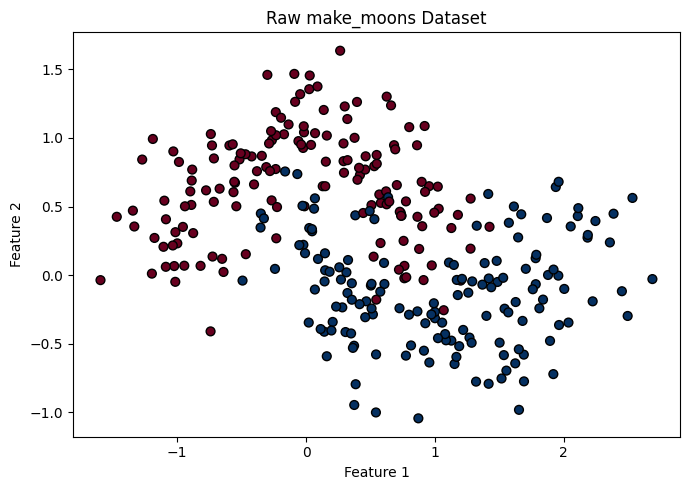

In [4]:
def plot_dataset(X, y):
    """
    Plot the original dataset.
    """
    plt.figure(figsize=(7, 5))
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="RdBu", edgecolors="black", s=40)
    plt.title("Raw make_moons Dataset")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.tight_layout()
    plt.show()

plot_dataset(X, y)

## Prepare the Data

The dataset is split into training and test sets so that model performance can be evaluated on unseen data.

Feature scaling is then applied because SVMs are sensitive to the magnitude of the input variables.

In [5]:
def prepare_data(X, y, test_size=0.3, random_state=42):
    """
    Split the dataset into training and test sets, then standardise features.
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    X_scaled = scaler.transform(X)

    return X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled, X_scaled

X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled, X_scaled = prepare_data(X, y)

## Feature Scaling: Before and After StandardScaler

SVMs are distance-based models — they compute the distance between data points when deciding where to place the decision boundary. If one feature has a much larger numerical range than another, the SVM will treat it as more important, even if it isn't.

**StandardScaler** transforms each feature to have **mean = 0** and **standard deviation = 1**. The plot below shows the dataset before and after scaling. The shape does not change — only the numerical range — but this step can make a large difference to SVM accuracy.

> **Important:** Always fit the scaler on **training data only** (`scaler.fit_transform(X_train)`), then apply it to the test set (`scaler.transform(X_test)`). Fitting on the full dataset leaks information and inflates your results.

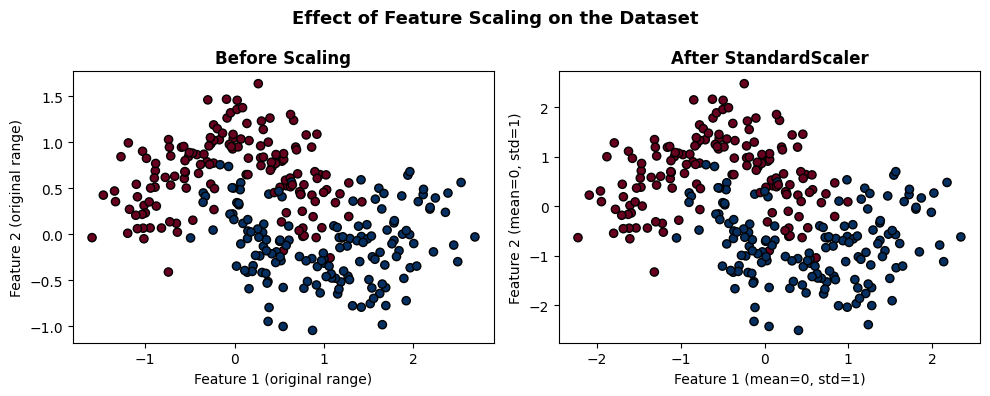

In [6]:
def plot_scaling_comparison(X, X_scaled):
    """
    Plot the dataset before and after StandardScaler to show the effect of feature scaling.
    Uses RdBu colourmap for colour-blind accessibility.
    """
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Before scaling
    axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu', edgecolors='black', s=35)
    axes[0].set_title('Before Scaling', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Feature 1 (original range)')
    axes[0].set_ylabel('Feature 2 (original range)')

    # After scaling
    axes[1].scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='RdBu', edgecolors='black', s=35)
    axes[1].set_title('After StandardScaler', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Feature 1 (mean=0, std=1)')
    axes[1].set_ylabel('Feature 2 (mean=0, std=1)')

    plt.suptitle('Effect of Feature Scaling on the Dataset', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('scaling_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_scaling_comparison(X, X_scaled)

**Figure description (accessibility):** Two scatter plots of the same two-class crescent dataset. The left plot shows the original feature ranges (approximately -1 to 2). The right plot shows both features re-centred at zero with unit variance (approximately -2 to 2), making the scale uniform across both axes.

## Build the SVM Models

Four SVM models are created for comparison:
- a **Linear** kernel
- a **Polynomial** kernel (degree 3)
- an **RBF** (Radial Basis Function) kernel
- a **Sigmoid** kernel

This makes it possible to observe how different kernels behave on the same dataset.

In [7]:
def build_models():
    """
    Create the SVM models to compare.
    """
    return {
        "Linear": SVC(kernel="linear", C=1.0),
        "Polynomial": SVC(kernel="poly", degree=3, C=1.0, gamma="scale"),
        "RBF": SVC(kernel="rbf", C=1.0, gamma="scale"),
        "Sigmoid": SVC(kernel="sigmoid", C=1.0, gamma="scale"),
    }

models = build_models()
models

{'Linear': SVC(kernel='linear'),
 'Polynomial': SVC(kernel='poly'),
 'RBF': SVC(),
 'Sigmoid': SVC(kernel='sigmoid')}

## Train and Evaluate the Models

Each model is trained on the training data and evaluated using both training accuracy and test accuracy.

Comparing training and test accuracy helps identify whether a model is underfitting or overfitting.

In [8]:
def train_and_evaluate(models, X_train_scaled, X_test_scaled, y_train, y_test):
    """
    Train each model and store accuracy results.
    """
    trained_models = {}
    results = []

    for name, model in models.items():
        model.fit(X_train_scaled, y_train)

        train_pred = model.predict(X_train_scaled)
        test_pred = model.predict(X_test_scaled)

        train_acc = accuracy_score(y_train, train_pred)
        test_acc = accuracy_score(y_test, test_pred)

        trained_models[name] = model
        results.append({
            "Kernel": name,
            "Train Accuracy": round(train_acc, 3),
            "Test Accuracy": round(test_acc, 3)
        })

    results_df = pd.DataFrame(results).sort_values(by="Test Accuracy", ascending=False)
    return trained_models, results_df

trained_models, results_df = train_and_evaluate(
    models, X_train_scaled, X_test_scaled, y_train, y_test
)

## Plot the Decision Boundaries

The figure below shows how each kernel changes the shape of the decision boundary.

The shaded regions represent predicted class areas, while the circled points indicate the support vectors that define the classifier.

In [9]:
def plot_decision_boundary(ax, model, X_plot, y_plot, title):
    """
    Plot decision regions, data points, and support vectors.
    """
    x_min, x_max = X_plot[:, 0].min() - 1, X_plot[:, 0].max() + 1
    y_min, y_max = X_plot[:, 1].min() - 1, X_plot[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 500),
        np.linspace(y_min, y_max, 500)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap="RdBu")
    ax.scatter(X_plot[:, 0], X_plot[:, 1], c=y_plot, cmap="RdBu", edgecolors="black", s=35)

    ax.scatter(
        model.support_vectors_[:, 0],
        model.support_vectors_[:, 1],
        s=120,
        facecolors="none",
        edgecolors="black",
        linewidths=1.5,
        label="Support Vectors"
    )

    ax.set_title(f"{title} Kernel")
    ax.set_xlabel("Scaled Feature 1")
    ax.set_ylabel("Scaled Feature 2")
    ax.legend(loc="upper right", fontsize=8)

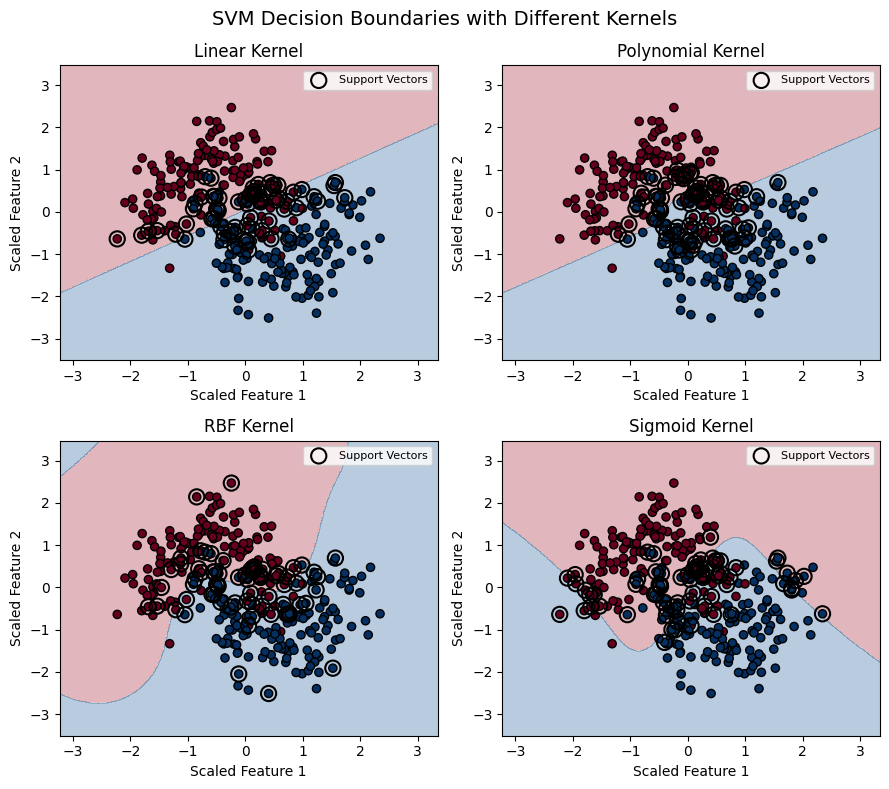

In [10]:
def plot_all_boundaries(trained_models, X_scaled, y, save_path="svm_kernel_comparison.png"):
    """
    Plot side-by-side decision boundaries for all kernels.
    """
    fig, axes = plt.subplots(2, 2, figsize=(9, 8))
    axes = axes.flatten()

    for ax, (name, model) in zip(axes, trained_models.items()):
        plot_decision_boundary(ax, model, X_scaled, y, name)

    plt.suptitle("SVM Decision Boundaries with Different Kernels", fontsize=14)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

plot_all_boundaries(trained_models, X_scaled, y)

**Figure description (accessibility):** The figure above shows four side-by-side scatter plots, one for each SVM kernel (Linear, Polynomial, RBF, Sigmoid). Each plot displays the two-class make\_moons dataset with a coloured decision region (red vs blue) separating the classes. Support vectors are highlighted with black circles. The Linear kernel produces a straight boundary that fails to separate the curved classes. The Polynomial and RBF kernels produce curved, flexible boundaries that closely follow the data structure. The Sigmoid kernel produces an irregular boundary with lower accuracy.

## Compare Accuracy

The table below compares training accuracy and test accuracy for each kernel.

A model with low performance on both training and test data may be underfitting, while a model with very high training accuracy but much lower test accuracy may be overfitting.

In [11]:
from IPython.display import display
display(results_df.style
    .set_caption("Table 1: Training vs Test Accuracy by Kernel")
    .format({'Train Accuracy': '{:.1%}', 'Test Accuracy': '{:.1%}'})
    .highlight_max(subset=['Test Accuracy'], color='lightgreen')
    .highlight_min(subset=['Test Accuracy'], color='#ffcccc')
)

,Kernel,Train Accuracy,Test Accuracy
2,RBF,91.0%,86.7%
0,Linear,87.1%,84.4%
1,Polynomial,87.1%,83.3%
3,Sigmoid,75.2%,73.3%


**Interpreting the results:**

- The **RBF kernel** typically achieves the highest test accuracy on the `make_moons` dataset because its Gaussian similarity function can model arbitrarily complex, non-linear boundaries.
- The **Polynomial kernel** also performs well, as a degree-3 polynomial can capture the curved structure of the data.
- The **Linear kernel** performs worst here — this is expected, since the two classes are not linearly separable. This illustrates the core limitation of linear SVMs on non-linear problems.
- The **Sigmoid kernel** often underperforms on this dataset because its behaviour is sensitive to the scaling of features and the `C` parameter, and it does not guarantee a positive semi-definite kernel matrix.

> **Key takeaway:** Kernel choice has a large impact on SVM performance. On non-linear data, RBF is a strong default choice, but the best kernel depends on the dataset.

## RBF Hyperparameter Sensitivity: Effect of γ and C

Choosing RBF is only half the battle — you also need to tune its two key hyperparameters:

| Parameter | What it controls | Too low → | Too high → |
|-----------|-----------------|-----------|------------|
| **γ (gamma)** | Width of the Gaussian function; how far each point's influence reaches | Very smooth, wide boundary (underfitting) | Tight boundary hugging each point (overfitting) |
| **C** | Penalty for misclassifying a training point | Soft, wider margin (allows misclassifications) | Forces correct classification of every point (overfitting) |

The figure below shows all four combinations of low/high γ and C, making the effect of each parameter immediately visible.

> **Best practice:** Use `GridSearchCV` or `RandomizedSearchCV` to tune γ and C together. A common starting grid is `C ∈ {0.1, 1, 10, 100}` and `γ ∈ {0.001, 0.01, 0.1, 1, 'scale'}`.

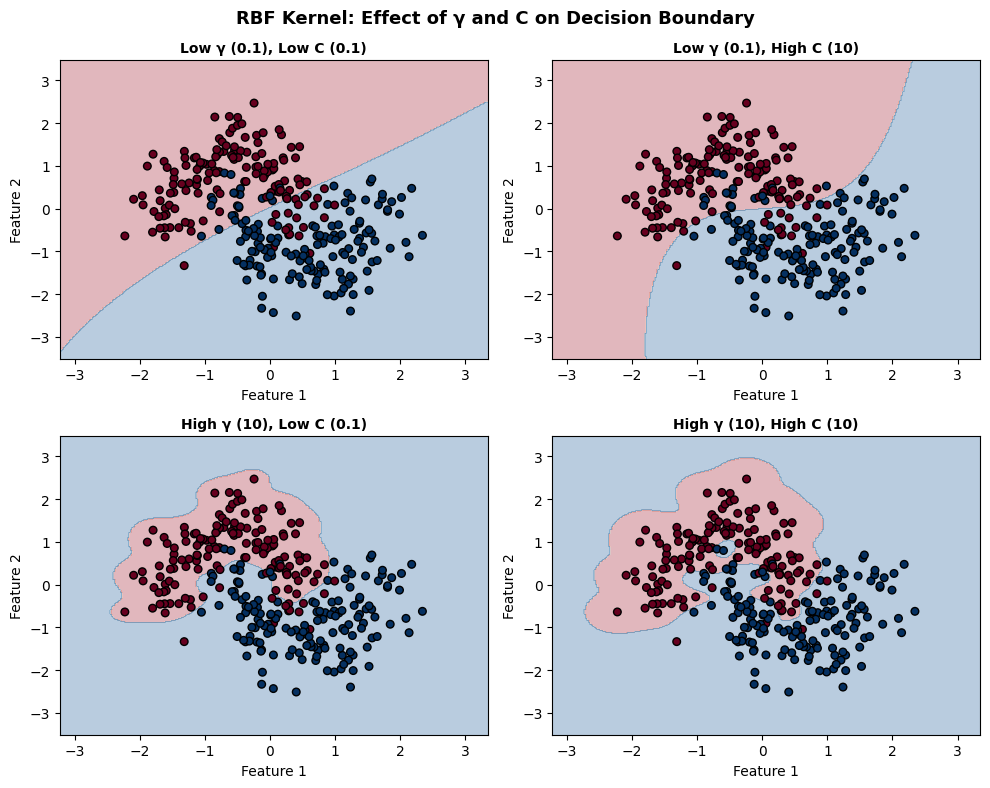

In [12]:
def plot_rbf_hyperparameters(X_train_scaled, y_train, X_scaled, y):
    """
    Show how different gamma and C values affect the RBF decision boundary.
    Demonstrates underfitting (low gamma/C) vs overfitting (high gamma/C).
    Uses RdBu colourmap for colour-blind accessibility.
    """
    configs = [
        ('Low γ (0.1), Low C (0.1)',  0.1,  0.1),
        ('Low γ (0.1), High C (10)',  0.1, 10.0),
        ('High γ (10), Low C (0.1)', 10.0,  0.1),
        ('High γ (10), High C (10)', 10.0, 10.0),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    axes = axes.flatten()

    for ax, (title, gamma, C) in zip(axes, configs):
        model = SVC(kernel='rbf', gamma=gamma, C=C)
        model.fit(X_train_scaled, y_train)

        x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
        y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1
        xx, yy = np.meshgrid(
            np.linspace(x_min, x_max, 300),
            np.linspace(y_min, y_max, 300)
        )
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

        ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
        ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='RdBu',
                   edgecolors='black', s=30)
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.set_xlabel('Feature 1')
        ax.set_ylabel('Feature 2')

    plt.suptitle('RBF Kernel: Effect of γ and C on Decision Boundary',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('rbf_hyperparams.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_rbf_hyperparameters(X_train_scaled, y_train, X_scaled, y)

**Figure description (accessibility):** Four scatter plots showing how the RBF decision boundary changes with different γ and C values. Top-left (low γ, low C): a very smooth, broad boundary that underfits. Top-right (low γ, high C): still smooth but slightly tighter. Bottom-left (high γ, low C): a tight boundary hugging only part of the data. Bottom-right (high γ, high C): a very tight, irregular boundary around individual points, risking overfitting.

## Conclusion

This tutorial demonstrated how the choice of kernel in a Support Vector Machine fundamentally changes the shape of the decision boundary and the model's classification performance.

Using the `make_moons` dataset — a non-linearly separable two-class problem — we compared four kernels:

| Kernel | What it does well | Limitation |
|--------|-------------------|------------|
| Linear | Fast, interpretable | Cannot handle non-linear data |
| Polynomial | Captures curved structure | Can overfit with high degree |
| RBF | Flexible, strong default | Sensitive to `C` and `gamma` tuning |
| Sigmoid | Neural-network-like | Inconsistent, not always valid kernel |

The **kernel trick** is the key insight behind all of these: instead of explicitly mapping data into a higher-dimensional space, the kernel function computes similarity between points in that space directly — making it computationally feasible to find non-linear decision boundaries.

**Practical guidance:** Start with RBF as your default kernel for non-linear problems, and use cross-validation to tune `C` and `gamma`. Switch to a linear kernel when your dataset is large and high-dimensional (e.g. text classification), where linear methods often perform comparably to non-linear ones at much lower cost.

## References

1. Cortes, C. & Vapnik, V. (1995). Support-vector networks. *Machine Learning*, 20(3), 273–297. https://doi.org/10.1007/BF00994018

2. Scikit-learn developers (2024). *sklearn.svm.SVC* — Scikit-learn documentation. https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html

3. Scikit-learn developers (2024). *Support Vector Machines* — Scikit-learn user guide. https://scikit-learn.org/stable/modules/svm.html

4. Müller, A. C. & Guido, S. (2016). *Introduction to Machine Learning with Python*. O'Reilly Media.

5. Pedregosa, F. et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830. https://jmlr.org/papers/v12/pedregosa11a.html